In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nalisha/nykaa-marketing-campaign-performance-dataset/nykaa_campaign_data.csv


# Introduction


This dataset represents marketing campaign performance data from Nykaa, focusing on key metrices such as impressions, clicks, leads, conversions etc.

The objective of this analysis is to evaluate campaign effectiveness, understand customer engagement patterns, and indentify factors driving performance across different marketing channels.

Through this analysis, our aim to uncover actionable insights that can help optimize marketing startegies.

# Libraries Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
nykaa = pd.read_csv('/kaggle/input/datasets/nalisha/nykaa-marketing-campaign-performance-dataset/nykaa_campaign_data.csv')

In [4]:
nykaa

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,NY-CMP-1000,Social Media,College Students,21,"WhatsApp, YouTube",57804,6156,3616,2355,1867515,111.03,6.14,Hindi,20.98,College Students,29-04-2025
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18,YouTube,91801,3321,1971,1357,1046247,180.83,3.26,Hindi,7.24,College Students,06-04-2025
2,NY-CMP-1002,Influencer,Youth,23,"WhatsApp, Google, YouTube",15536,2182,952,755,197055,90.60,1.88,English,25.03,College Students,14-01-2025
3,NY-CMP-1003,Email,Working Women,18,"YouTube, Facebook, Instagram",88114,8413,2231,947,376906,249.07,0.60,Hindi,13.15,College Students,04-06-2025
4,NY-CMP-1004,Paid Ads,College Students,10,"Facebook, Instagram",96871,3743,2060,1258,518296,228.60,0.80,Hindi,7.29,Tier 2 City Customers,29-12-2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55550,NY-CMP-56550,SEO,Youth,16,"Instagram, Email",31041,3849,1012,639,162945,374.90,-0.32,Tamil,17.72,Tier 2 City Customers,16-02-2025
55551,NY-CMP-56551,Paid Ads,Tier 2 City Customers,26,Facebook,27335,3715,2184,1006,792728,56.38,12.98,English,25.26,Premium Shoppers,18-11-2024
55552,NY-CMP-56552,Influencer,Tier 2 City Customers,23,"WhatsApp, Facebook, Instagram",43481,6447,3751,1668,383640,56.18,3.09,Bengali,27.29,Working Women,24-10-2024
55553,NY-CMP-56553,Social Media,College Students,16,"Facebook, Email",33530,2518,584,299,194051,227.53,1.85,Bengali,10.14,Working Women,22-05-2025


In [5]:
nykaa.shape

(55555, 16)

In [6]:
nykaa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55555 entries, 0 to 55554
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       55555 non-null  object 
 1   Campaign_Type     55555 non-null  object 
 2   Target_Audience   55555 non-null  object 
 3   Duration          55555 non-null  int64  
 4   Channel_Used      55555 non-null  object 
 5   Impressions       55555 non-null  int64  
 6   Clicks            55555 non-null  int64  
 7   Leads             55555 non-null  int64  
 8   Conversions       55555 non-null  int64  
 9   Revenue           55555 non-null  int64  
 10  Acquisition_Cost  55555 non-null  float64
 11  ROI               55555 non-null  float64
 12  Language          55555 non-null  object 
 13  Engagement_Score  55555 non-null  float64
 14  Customer_Segment  55555 non-null  object 
 15  Date              55555 non-null  object 
dtypes: float64(3), int64(6), object(7)
memor

In [7]:
nykaa.isnull().sum()

Campaign_ID         0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Impressions         0
Clicks              0
Leads               0
Conversions         0
Revenue             0
Acquisition_Cost    0
ROI                 0
Language            0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64

In [8]:
nykaa.describe()

,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Engagement_Score
count,55555.000000,55555.000000,55555.000000,55555.000000,55555.000000,5.555500e+04,55555.000000,55555.000000,55555.000000
mean,17.446044,55087.885357,4688.070507,1877.271119,1032.866925,5.158197e+05,377.347068,2.713807,13.784169
std,7.520438,25930.001514,3178.686285,1435.636117,862.496788,4.900121e+05,541.084524,4.493380,6.353125
min,5.000000,10001.000000,202.000000,56.000000,19.000000,6.183000e+03,9.080000,-0.970000,2.600000
25%,11.000000,32680.000000,2110.000000,779.000000,400.000000,1.777060e+05,105.435000,0.040000,8.360000
50%,17.000000,55182.000000,3907.000000,1481.000000,779.000000,3.604360e+05,207.510000,1.240000,13.600000
75%,24.000000,77514.500000,6688.000000,2605.000000,1414.000000,6.874225e+05,428.580000,3.630000,18.855000
max,30.000000,100000.000000,14868.000000,8876.000000,6686.000000,4.579910e+06,15473.160000,74.420000,30.910000


In [9]:
nykaa['Date'] = pd.to_datetime(nykaa['Date'], format='mixed')

In [10]:
nykaa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55555 entries, 0 to 55554
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Campaign_ID       55555 non-null  object        
 1   Campaign_Type     55555 non-null  object        
 2   Target_Audience   55555 non-null  object        
 3   Duration          55555 non-null  int64         
 4   Channel_Used      55555 non-null  object        
 5   Impressions       55555 non-null  int64         
 6   Clicks            55555 non-null  int64         
 7   Leads             55555 non-null  int64         
 8   Conversions       55555 non-null  int64         
 9   Revenue           55555 non-null  int64         
 10  Acquisition_Cost  55555 non-null  float64       
 11  ROI               55555 non-null  float64       
 12  Language          55555 non-null  object        
 13  Engagement_Score  55555 non-null  float64       
 14  Customer_Segment  5555

# Summary of Campaign Performance

In [11]:
print("="*45)
print("       Summary of Campaign Performance")
print("="*45)
result = nykaa[['Revenue', 'Impressions', 'Clicks', 'Leads', 'Acquisition_Cost' ]].sum()

for col, val in result.items():
    print(f"{col}:  {val:,.0f}")


# a = total click/total impressions
nykaa['Total_cost']= nykaa['Acquisition_Cost']*nykaa['Conversions']

total_cost = nykaa['Total_cost'].sum()

total_clicks = nykaa['Clicks'].sum()
total_impressions = nykaa['Impressions'].sum()
total_aquis = nykaa['Acquisition_Cost'].sum()
total_leads = nykaa['Leads'].sum()
total_conversion = nykaa['Conversions'].sum()

CTR = total_clicks/total_impressions
CPC = total_cost/total_clicks
CPL = total_cost/total_leads
CPA = total_cost/total_conversion

print("\n----Campaign Metrics----")
print(f"Click through Rate(CTR): {CTR:.2%}") 
print(f"Cost Per Click(CPC): {CPC:.1f}") 
print(f"Cost Per lead(CPL): {CPL:.1f}")
print(f"Cost Per Action (CPA): {CPL:.1f}")


       Summary of Campaign Performance
Revenue:  28,656,364,282
Impressions:  3,060,407,471
Clicks:  260,445,757
Leads:  104,291,797
Acquisition_Cost:  20,963,516

----Campaign Metrics----
Click through Rate(CTR): 8.51%
Cost Per Click(CPC): 37.2
Cost Per lead(CPL): 93.0
Cost Per Action (CPA): 93.0


In [12]:
nykaa.groupby('Campaign_Type')['Total_cost'].agg(['sum', 'mean','max']).sort_values(by = "sum", ascending = False).astype(int)

,sum,mean,max
Campaign_Type,,,
Influencer,1956049185,175682,299991
Paid Ads,1944144592,174896,299981
Email,1938898437,174486,299981
Social Media,1935245566,174126,299999
SEO,1924787081,173732,299993


In [13]:
nykaa['ROAS'] = nykaa['Revenue']/nykaa['Total_cost'] # Return on Ad spend
nykaa['Profit'] = nykaa['Revenue'] - nykaa['Total_cost'] 
print(nykaa[['ROAS', 'Profit']])

            ROAS      Profit
0       7.142214  1606039.35
1       4.263673   800860.69
2       2.880795   128652.00
3       1.597944   141036.71
4       1.802275   230717.20
...          ...         ...
55550   0.680181   -76616.10
55551  13.976587   736009.72
55552   4.093984   289931.76
55553   2.852371   126019.53
55554   9.740815   581249.66

[55555 rows x 2 columns]


In [14]:
nykaa['Target_Audience'].value_counts()

Target_Audience
Working Women            11224
Premium Shoppers         11182
Tier 2 City Customers    11100
College Students         11078
Youth                    10971
Name: count, dtype: int64

In [15]:
target_audi = nykaa.groupby('Target_Audience')['Total_cost'].agg(['sum',
                                                                  'mean', 
                                                                  'max']).sort_values(
    by ="sum",ascending = False).astype(int)
print(target_audi)

                              sum    mean     max
Target_Audience                                  
Working Women          1960966058  174711  299970
Premium Shoppers       1947169436  174134  299991
Tier 2 City Customers  1943605053  175099  299991
College Students       1940483192  175165  299999
Youth                  1906901121  173812  299981


In [16]:
nykaa['Channel_Used'].value_counts().head(5)

Channel_Used
Instagram    3178
YouTube      3150
WhatsApp     3096
Google       3092
Email        3060
Name: count, dtype: int64

In [17]:
nykaa['Channel_Used'].count()

np.int64(55555)

# Engagement of channels

In [18]:
# Which channel contributes the most total engagement volume.
channel_engagement = nykaa.groupby('Channel_Used')['Engagement_Score'].sum().sort_values(
    ascending = False).head(5)
percentage_engaged = (channel_engagement/channel_engagement.sum())*100
print(f"Total Engagement Share by Channel: {percentage_engaged.round(2).astype(str)+"%"}")

Total Engagement Share by Channel: Channel_Used
Instagram    20.41%
YouTube      20.12%
Google       19.96%
WhatsApp     19.76%
Email        19.74%
Name: Engagement_Score, dtype: object


Instagram contributed the highest share of overall campaign engagement, making it the strongest awareness driving channel.

In [19]:
# Which channel performs better on average.
avg_engagement = nykaa.groupby('Channel_Used')['Engagement_Score'].mean().sort_values(ascending = False).head(5)
percentage = (avg_engagement/avg_engagement.sum())*100
print(f"Top Channels by Average Engagement Score: {percentage.round(2)}")

Top Channels by Average Engagement Score: Channel_Used
Facebook, YouTube, Email       20.29
Instagram, WhatsApp, Google    20.04
Email, WhatsApp, Facebook      19.93
WhatsApp, Facebook             19.93
Instagram, Google, Email       19.81
Name: Engagement_Score, dtype: float64


Facebook, YouTube, and Email campaigns showed identical average engagement performance, indicating balanced audience interaction across these channels.

In [20]:
nykaa.columns

Index(['Campaign_ID', 'Campaign_Type', 'Target_Audience', 'Duration',
       'Channel_Used', 'Impressions', 'Clicks', 'Leads', 'Conversions',
       'Revenue', 'Acquisition_Cost', 'ROI', 'Language', 'Engagement_Score',
       'Customer_Segment', 'Date', 'Total_cost', 'ROAS', 'Profit'],
      dtype='object')

# Yearly performance

In [21]:
nykaa['Date'] = pd.to_datetime(nykaa['Date'])

nykaa['Year'] = nykaa['Date'].dt.year

In [22]:
yearly_report = nykaa.groupby('Year').agg({
    'Revenue':'sum',
    'Profit':'sum',
    'ROI':'mean',
    'ROAS':'mean',
    'Engagement_Score':'mean',
    'Conversions':'sum'
}).round(2)

# Convert into readable format
yearly_report['Revenue_Billion'] = (
    yearly_report['Revenue'] / 1_000_000_000
).round(2)

yearly_report['Profit_Billion'] = (
    yearly_report['Profit'] / 1_000_000_000
).round(2)

yearly_report['Conversions_Million'] = (
    yearly_report['Conversions'] / 1_000_000
).round(2)

# Select only readable columns
final_report = yearly_report[[
    'Revenue_Billion',
    'Profit_Billion',
    'ROI',
    'ROAS',
    'Engagement_Score',
    'Conversions_Million'
]]

print("="*50)
print("      Yearly Marketing Performance Report")
print("="*50)

print(final_report)

      Yearly Marketing Performance Report
      Revenue_Billion  Profit_Billion   ROI  ROAS  Engagement_Score  \
Year                                                                  
2024            15.31           10.15  2.72  3.72             13.79   
2025            13.34            8.81  2.71  3.71             13.77   

      Conversions_Million  
Year                       
2024                30.62  
2025                26.76  


# Nykaa Visualization

In [23]:
nykaa.columns

Index(['Campaign_ID', 'Campaign_Type', 'Target_Audience', 'Duration',
       'Channel_Used', 'Impressions', 'Clicks', 'Leads', 'Conversions',
       'Revenue', 'Acquisition_Cost', 'ROI', 'Language', 'Engagement_Score',
       'Customer_Segment', 'Date', 'Total_cost', 'ROAS', 'Profit', 'Year'],
      dtype='object')

# Distibution of Metrices

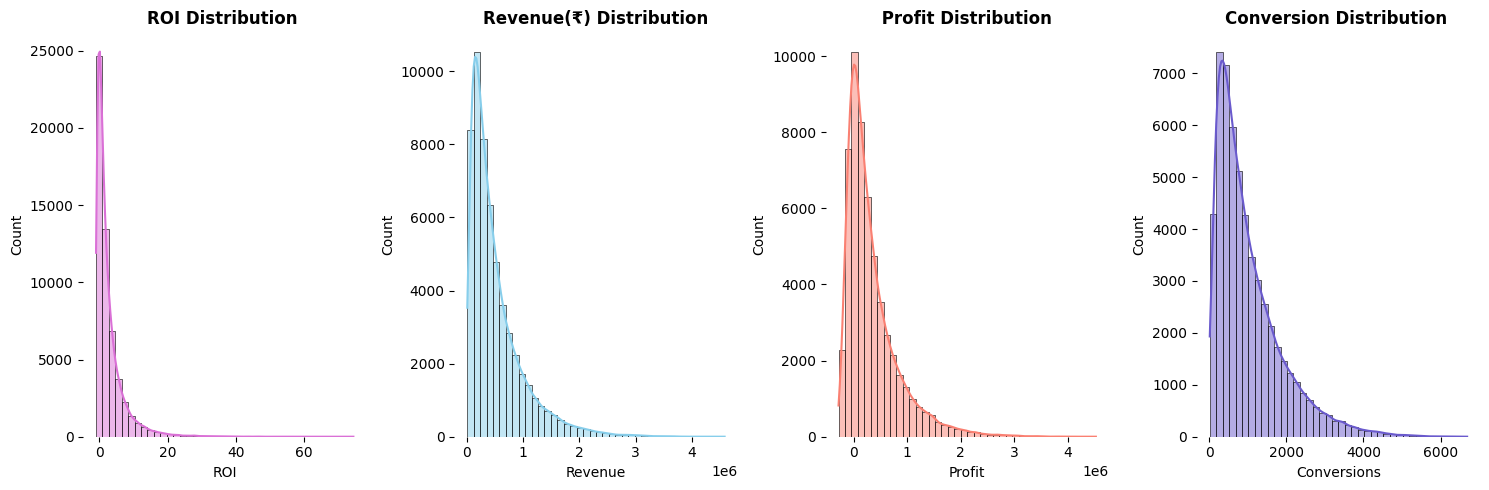

Revenue — Mean: 515,820 | Median: 360,436 | Std: 490,012
ROI     — Mean: 2.71 | Median: 1.24 | Negative ROI campaigns: 13220


In [24]:
fig, ax = plt.subplots(1, 4, figsize = (15, 5))
sns.histplot(nykaa['ROI'], color='orchid', bins=40, 
        ax = ax[0], kde = True)
ax[0].set_title("ROI Distribution ", fontweight='bold')
sns.despine(ax=ax[0], left =True, bottom = True)
ax[0].set_xlabel('ROI')


sns.histplot(nykaa['Revenue'], color='skyblue', bins=40, ax= ax[1],
             kde = True)
ax[1].set_title("Revenue(₹) Distribution", fontweight='bold')
sns.despine(ax=ax[1], left =True, bottom = True)


sns.histplot(nykaa['Profit'], color='salmon', bins=40, 
           kde = True,
          ax = ax[2])
ax[2].set_title(" Profit Distribution ", fontweight='bold')
sns.despine(ax=ax[2], left =True, bottom = True)


sns.histplot(nykaa['Conversions'], color='slateblue', bins=40,
            ax= ax[3], 
            kde = True)
ax[3].set_title("Conversion Distribution ",  fontweight='bold')
sns.despine(ax=ax[3], left =True, bottom = True)



plt.tight_layout()
plt.show()

print(f"Revenue — Mean: {nykaa['Revenue'].mean():,.0f} | Median: {nykaa['Revenue'].median():,.0f} | Std: {nykaa['Revenue'].std():,.0f}")
print(f"ROI     — Mean: {nykaa['ROI'].mean():.2f} | Median: {nykaa['ROI'].median():.2f} | Negative ROI campaigns: {(nykaa['ROI'] < 0).sum()}")

### ROI:
The average ROI(2.71) is higher than the median(1.24), indicating that while some campaigns are highly profitable, many campaigns deliver moderate or low returns. Number of campaign show negative ROI which Highlighting inefficiencies.

### Revenue:
The average revenue(₹515,820) is significantly higher than the median(₹360,436), suggesting the presence of high value outliers driving overall revenue.

### Profit:
Profit Distribution follows a similar skewed pattern, where a few campaigns contribute disproportionately to total profit, while the majority generate lower returns.

### Conversion:
Conversion data is also right skewed suggesting that only a few campaigns achieve very high conversions, while most campaigns perform at lower scale.

**Overall :**
This analysis reveals that campaign performance is highly uneven, with a small number of campaigns driving the majority of revenue, profit and conversions.

# Weightage of channel Engagement

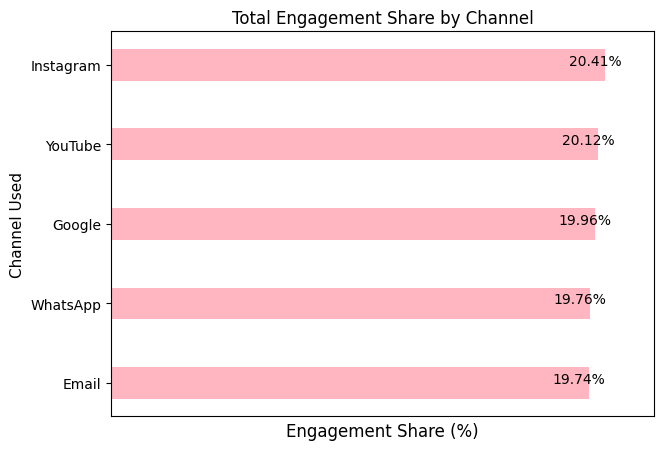

In [25]:
plt.figure(figsize = (7,5))
plt.barh(percentage_engaged.index,
         percentage_engaged.values,
        height = 0.4,
        color = 'lightpink')
plt.title("Total Engagement Share by Channel")
plt.xlabel("Engagement Share (%)", fontsize = 12)
plt.ylabel("Channel Used", fontsize = 11)
plt.xticks([])



# Highest at Top
plt.gca().invert_yaxis()

# Add Space for Text
plt.xlim(0, percentage_engaged.max() + 2)


# Show Percentage on Bars
for index, value in enumerate(percentage_engaged.values):
    plt.text(value - 1.5, index, f"{value:.2f}%")
#sns.despine(left =True, bottom = True)
plt.show()

**Instagram** leads all channels with the highest engagement share of **20.41%** followed closely by Youtube and Google, indicating strong performance of social media platforms.

In [26]:
nykaa['Language'].value_counts()

Language
Hindi      13986
Tamil      13884
English    13874
Bengali    13811
Name: count, dtype: int64

In [27]:
nykaa['Customer_Segment'].value_counts()

Customer_Segment
College Students         11293
Working Women            11123
Youth                    11088
Premium Shoppers         11059
Tier 2 City Customers    10992
Name: count, dtype: int64

# Categories of Campaign and Audience

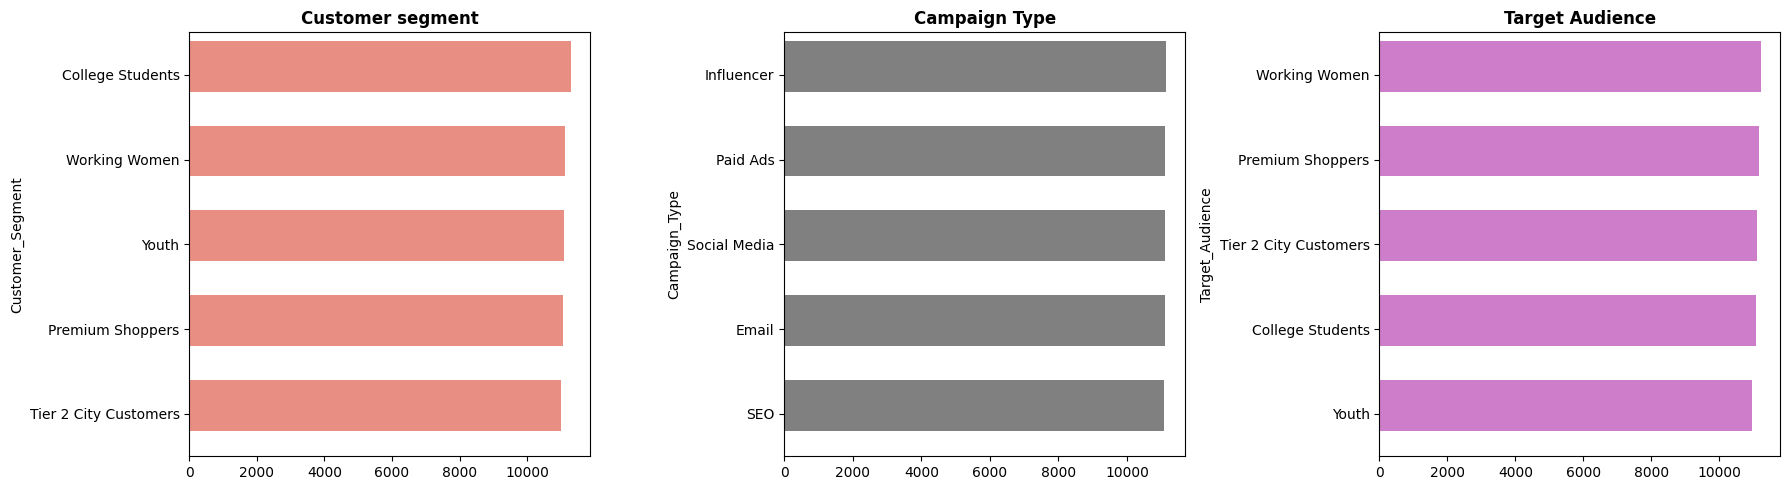

In [28]:
fig, ax = plt.subplots(1, 3, figsize = (18,5))
cs = nykaa['Customer_Segment'].value_counts().sort_values(ascending = False)
sns.barplot(x = cs.values, y = cs.index, ax = ax[0], color= 'salmon', height = 0.6)
ax[0].set_title("Customer segment", fontweight = 'bold')


ct = nykaa['Campaign_Type'].value_counts().sort_values(ascending = False)
sns.barplot(x = ct.values, y = ct.index, ax = ax[1], color= 'grey', height = 0.6)
ax[1].set_title("Campaign Type", fontweight = 'bold')


ta = nykaa['Target_Audience'].value_counts().sort_values(ascending = False)
sns.barplot(x = ta.values, y = ta.index, ax = ax[2], color= 'orchid', height = 0.6)
ax[2].set_title("Target Audience", fontweight = 'bold')
#sns.despine(ax=ax[2], left =False, bottom = True)

plt.tight_layout()
plt.show()


In [29]:
nykaa.columns

Index(['Campaign_ID', 'Campaign_Type', 'Target_Audience', 'Duration',
       'Channel_Used', 'Impressions', 'Clicks', 'Leads', 'Conversions',
       'Revenue', 'Acquisition_Cost', 'ROI', 'Language', 'Engagement_Score',
       'Customer_Segment', 'Date', 'Total_cost', 'ROAS', 'Profit', 'Year'],
      dtype='object')

# Marketing Performance

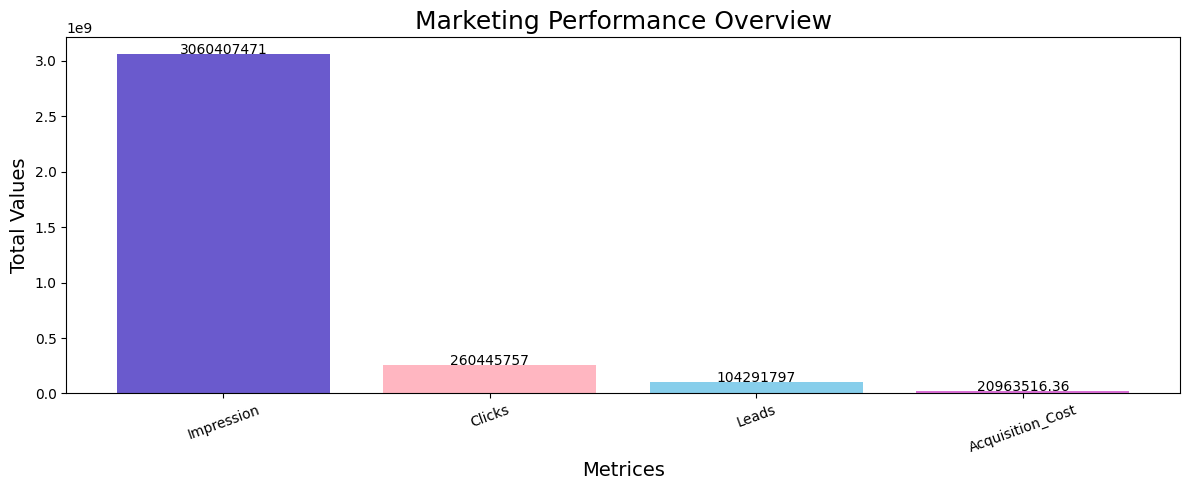

In [30]:
metrices = ["Impression", "Clicks","Leads", "Acquisition_Cost"]


values =  [nykaa['Impressions'].sum(),
           nykaa['Clicks'].sum(),
           nykaa["Leads"].sum(),
           nykaa['Acquisition_Cost'].sum()
          ]

colors = ['slateblue','lightpink', 'skyblue', 'orchid']
plt.figure(figsize=(12,5))
plt.bar(metrices, values, color = colors)
plt.title("Marketing Performance Overview", fontsize = 18)
plt.xlabel("Metrices", fontsize = 14)
plt.ylabel("Total Values", fontsize = 14)
plt.xticks(rotation = 20)

for i, v in enumerate(values):
    plt.text(i,v, str(round(v, 2)), ha = 'center')

plt.tight_layout()
plt.show()

**Impressions** reaching over billions, which is extremely high campaign reach, and clicks and leads is relatively lower which suggest a drop-off in user engagement.